In [1]:
import sys

from gears import PertData, GEARS

In [2]:
pert_data = PertData('../../data/raw_download/GEARS_data/') # specific saved folder
pert_data.load(data_name = 'norman') # specific dataset name
pert_data.prepare_split(split = 'simulation', seed = 1) # get data split with seed 
pert_data.get_dataloader(batch_size = 32, test_batch_size = 128) # prepare data loader

Downloading...
100%|██████████| 9.46M/9.46M [00:02<00:00, 4.27MiB/s]
Downloading...
100%|██████████| 169M/169M [00:16<00:00, 10.5MiB/s] 
Extracting zip file...
Done!
Downloading...
100%|██████████| 559k/559k [00:00<00:00, 568kiB/s]  
These perturbations are not in the GO graph and their perturbation can thus not be predicted
['RHOXF2BB+ctrl' 'LYL1+IER5L' 'ctrl+IER5L' 'KIAA1804+ctrl' 'IER5L+ctrl'
 'RHOXF2BB+ZBTB25' 'RHOXF2BB+SET']
Creating pyg object for each cell in the data...
Creating dataset file...
100%|██████████| 277/277 [03:01<00:00,  1.52it/s]
Done!
Saving new dataset pyg object at ../../data/raw_download/GEARS_data/norman/data_pyg/cell_graphs.pkl
Done!
Creating new splits....
Saving new splits at ../../data/raw_download/GEARS_data/norman/splits/norman_simulation_1_0.75.pkl
Simulation split test composition:
combo_seen0:9
combo_seen1:43
combo_seen2:19
unseen_single:36
Done!
Creating dataloaders....
Done!


In [3]:
# Print the overall structure
print(pert_data.adata)

AnnData object with n_obs × n_vars = 89357 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name', 'split'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'


In [4]:
# Look at the first 5 cells and their metadata
print(pert_data.adata.obs.head())

# See all the different conditions/perturbations in the dataset
print(pert_data.adata.obs['condition'].value_counts())

# Check the splits (corrected column name)
print(pert_data.adata.obs['split'].value_counts())

                        condition cell_type dose_val  control  \
cell_barcode                                                    
AAACCTGAGGCATGTG-1   TSC22D1+ctrl      A549      1+1        0   
AAACCTGAGGCCCTTG-1    KLF1+MAP2K6      A549      1+1        0   
AAACCTGCACGAAGCA-1           ctrl      A549        1        1   
AAACCTGCAGACGTAG-1  CEBPE+RUNX1T1      A549      1+1        0   
AAACCTGCAGCCTTGG-1     MAML2+ctrl      A549      1+1        0   

                            condition_name  split  
cell_barcode                                       
AAACCTGAGGCATGTG-1   A549_TSC22D1+ctrl_1+1  train  
AAACCTGAGGCCCTTG-1    A549_KLF1+MAP2K6_1+1    val  
AAACCTGCACGAAGCA-1             A549_ctrl_1  train  
AAACCTGCAGACGTAG-1  A549_CEBPE+RUNX1T1_1+1  train  
AAACCTGCAGCCTTGG-1     A549_MAML2+ctrl_1+1  train  
condition
ctrl             7353
CEBPE+RUNX1T1    1030
KLF1+ctrl         997
TBX3+TBX2         969
SLC4A1+ctrl       853
                 ... 
PLK4+STIL          66
SAMD1+TGFBR2    

In [5]:
# Look at the first 5 genes
print(pert_data.adata.var.head())

# Get a list of all gene names
gene_names = pert_data.adata.var_names.tolist()

                    gene_name
gene_id                      
ENSG00000239945  RP11-34P13.8
ENSG00000223764   RP11-54O7.3
ENSG00000187634        SAMD11
ENSG00000187642         PERM1
ENSG00000188290          HES4


In [6]:
# Check the shape of the data matrix (should be Cells x Genes)
print(pert_data.adata.X.shape)

# If you want to see the expression values for the first 5 cells and first 5 genes
# (We use .toarray() because it is likely a sparse matrix)
print(pert_data.adata.X[:5, :5].toarray())

(89357, 5045)
[[0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.89266217]
 [0.         0.         0.         0.         0.5291838 ]]


In [7]:
# Check if a 'counts' layer exists
print(pert_data.adata.layers.keys())

# Check if the raw matrix was preserved
print(pert_data.adata.raw is not None)

KeysView(Layers with keys: counts)
False


In [8]:
# Check the first 5 cells and 5 genes without .toarray()
print(pert_data.adata.layers['counts'][:6, :6])

[[0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0. 0.]]


In [9]:
# Check the maximum value in the counts layer
print(pert_data.adata.layers['counts'].max())

3718.0


### swap the raw counts back, instead of transoformed

In [10]:
import scipy.sparse as sp

# 1. Compress the dense counts array into a sparse matrix
sparse_raw_counts = sp.csr_matrix(pert_data.adata.layers['counts'])

# 2. Overwrite .X with this sparse raw count matrix
pert_data.adata.X = sparse_raw_counts

# 3. Verify the swap worked (checking the type and a small slice)
print(type(pert_data.adata.X))
print(pert_data.adata.X[:6, :6].toarray())

<class 'scipy.sparse._csr.csr_matrix'>
[[0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0. 0.]]


Text(0.5, 1.0, 'Distribution of Non-Zero Raw Counts (Log Scale)')

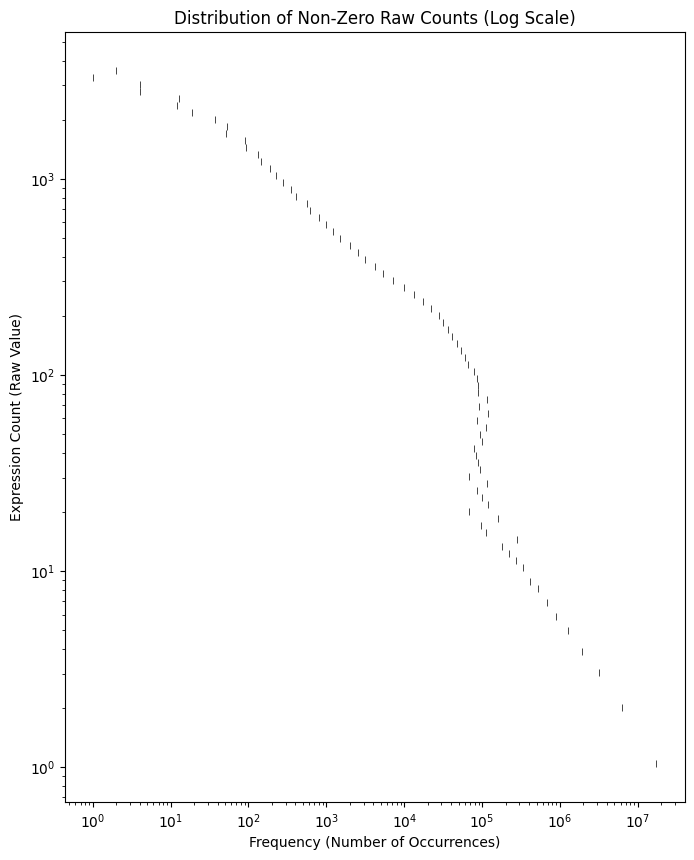

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

# 1. Extract only the non-zero counts to make the plot readable
if sp.issparse(pert_data.adata.X):
    # If it's already a sparse matrix, .data gets just the non-zero elements
    non_zero_counts = pert_data.adata.X.data
else:
    # If it's still dense, filter it
    non_zero_counts = pert_data.adata.X[pert_data.adata.X > 0]

# 2. Create the plot
plt.figure(figsize=(8, 10))

# We orient it with y as the expression count and x as the frequency (cell-gene pairs)
# log_scale=(True, True) handles the massive drop-off from 1 to 3718
sns.histplot(y=non_zero_counts, bins=100, log_scale=(True, True), color="blue")

plt.ylabel("Expression Count (Raw Value)")
plt.xlabel("Frequency (Number of Occurrences)")
plt.title("Distribution of Non-Zero Raw Counts (Log Scale)")

# # 3. Save the figure to your working directory
# plt.savefig("raw_counts_distribution.png", bbox_inches="tight")
# print("Plot successfully saved as 'raw_counts_distribution.png'")

In [12]:
# Choose a descriptive filename so you don't mix it up with the normalized GEARS version
save_path = "../../data/processed/norman_2019_raw_count_sparse_from_GEARS.h5ad"

# Write the AnnData object to disk
pert_data.adata.write_h5ad(save_path)

print(f"Successfully saved to {save_path}")

Successfully saved to ../../data/processed/norman_2019_raw_count_sparse_from_GEARS.h5ad


In [13]:
# 1. Generate the GEARS split exactly as you planned
pert_data.prepare_split(split='simulation', seed=42)

# 2. Extract the lists of perturbations assigned to each split
train_conditions = set(pert_data.set2conditions['train'])
val_conditions = set(pert_data.set2conditions['val'])
test_conditions = set(pert_data.set2conditions['test'])

# 3. Create a helper function to label each cell
def assign_split(condition):
    if condition in train_conditions:
        return 'train'
    elif condition in val_conditions:
        return 'val'
    elif condition in test_conditions:
        return 'test'
    else:
        return 'dropped' # Catch-all for any unassigned cells

# 4. Map the condition of each cell to its corresponding split
pert_data.adata.obs['gears_split'] = pert_data.adata.obs['condition'].apply(assign_split)

# 5. Verify the split distribution
print(pert_data.adata.obs['gears_split'].value_counts())

# 6. NOW save the fully prepped file (Raw Sparse Counts + Split Metadata)
save_path = "../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad"
pert_data.adata.write_h5ad(save_path)
print(f"Data prepped and saved to: {save_path}")

Creating new splits....
Saving new splits at ../../data/raw_download/GEARS_data/norman/splits/norman_simulation_42_0.75.pkl
Simulation split test composition:
combo_seen0:5
combo_seen1:55
combo_seen2:17
unseen_single:37
Done!


gears_split
train    47192
test     30969
val      11196
Name: count, dtype: int64
Data prepped and saved to: ../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad
